# Análisis de algoritmo paralelo kNN

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [2]:
df  = pd.read_csv('results/knn_cluster_results_v2.csv')
df.head()

,Processes,Subset_%,N_train,N_test,T_comp (s),T_comm (s),T_reduce (s),T_total (s),GFLOP/s,Accuracy
0,1,25,14000,3500,322.604331,0.000000,0.000000,322.604331,0.357243,0.960571
1,1,50,28000,7000,1269.102682,0.000000,0.000000,1269.102682,0.363242,0.964000
2,1,75,42000,10500,2814.713960,0.000000,0.000000,2814.713960,0.368504,0.969333
3,1,100,56000,14000,5047.164542,0.000000,0.000000,5047.164542,0.365347,0.972643
4,2,25,14000,3500,171.872005,0.130004,0.046829,172.048850,0.335273,0.960571


In [3]:
t1_map = df[df['Processes'] == 1].set_index('Subset_%')['T_total (s)'].to_dict()
df['T_s_base'] = df['Subset_%'].map(t1_map)
df['Speedup'] = df['T_s_base'] / df['T_total (s)']
df['Efficiency'] = df['Speedup'] / df['Processes']

df.drop(columns=['T_s_base'], inplace=True)

df_100 = df[df['Subset_%'] == 100].copy()
df_100.reset_index(drop=True, inplace=True)

df_100

,Processes,Subset_%,N_train,N_test,T_comp (s),T_comm (s),T_reduce (s),T_total (s),GFLOP/s,Accuracy,Speedup,Efficiency
0,1,100,56000,14000,5047.164542,0.000000,0.000000,5047.164542,0.365347,0.972643,1.000000,1.000000
1,2,100,56000,14000,2577.079628,0.492000,0.142386,2577.714026,0.357763,0.972643,1.958000,0.979000
2,4,100,56000,14000,1303.417338,0.478419,0.158445,1304.054212,0.353680,0.972643,3.870364,0.967591
3,8,100,56000,14000,774.350368,0.515309,0.206095,775.071783,0.297664,0.972643,6.511867,0.813983
4,16,100,56000,14000,447.383347,34.337667,0.373958,482.094987,0.257605,0.972643,10.469233,0.654327
5,32,100,56000,14000,405.685812,68.751797,1.027767,475.465402,0.142041,0.972643,10.615209,0.331725


### Tiempos de ejecución $T_{comp}$, $T_{comm}$, $T_{total}$

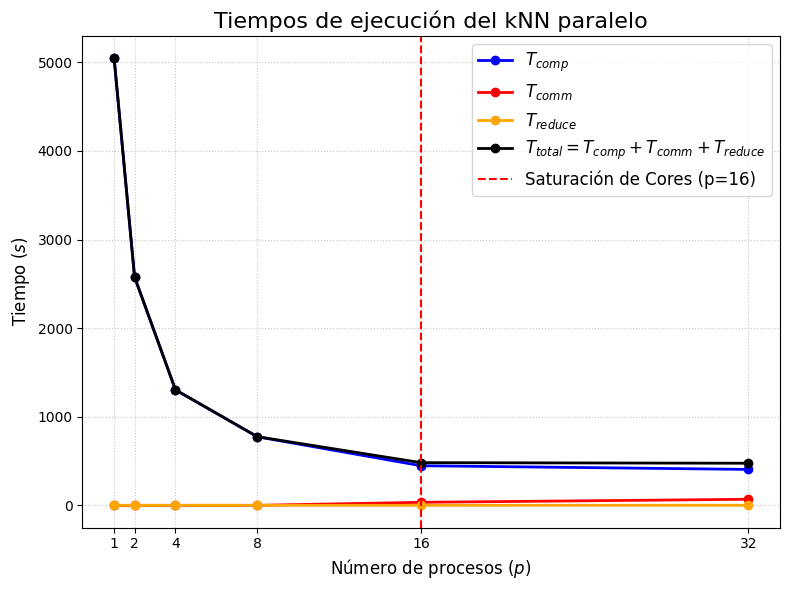

In [4]:
plt.figure(figsize=(8, 6))

plt.plot(df_100['Processes'], df_100['T_comp (s)'], marker='o', linestyle='-', color='b', label='$T_{comp}$', linewidth=2)
plt.plot(df_100['Processes'], df_100['T_comm (s)'], marker='o', linestyle='-', color='r', label='$T_{comm}$', linewidth=2)
plt.plot(df_100['Processes'], df_100['T_reduce (s)'], marker='o', linestyle='-', color='orange', label='$T_{reduce}$', linewidth=2)
plt.plot(df_100['Processes'], df_100['T_total (s)'], marker='o', linestyle='-', color='black', label='$T_{total} = T_{comp} + T_{comm} + T_{reduce}$', linewidth=2)

plt.axvline(x=16, color='red', linestyle='--', linewidth=1.5, label='Saturación de Cores (p=16)')

plt.title('Tiempos de ejecución del kNN paralelo', fontsize=16)
plt.xlabel('Número de procesos ($p$)', fontsize=12)
plt.ylabel('Tiempo ($s$)', fontsize=12)
plt.grid(True, linestyle=":", alpha=0.7)
plt.xticks(df_100['Processes'])
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("imgs/PRAM_Times_Plot.png", dpi=300, bbox_inches='tight')
plt.show()

### Cómputo $T_{comp}$ vs Comunicación $T_{comm}$ vs Reducción Secuencial $T_{reduce}$

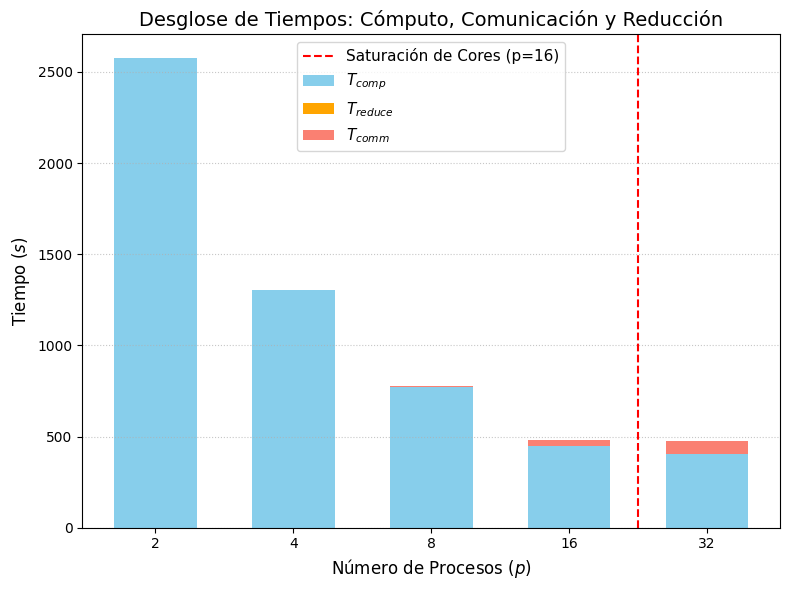

In [5]:
plt.figure(figsize=(8, 6))

df_mpi = df_100[df_100['Processes'] > 1]
x_labels_bar = df_mpi['Processes'].astype(str)

plt.bar(x_labels_bar, df_mpi['T_comp (s)'], color='skyblue', label='$T_{comp}$', width=0.6)

plt.bar(x_labels_bar, df_mpi['T_reduce (s)'], 
        bottom=df_mpi['T_comp (s)'], 
        color='orange', label='$T_{reduce}$', width=0.6)

plt.bar(x_labels_bar, df_mpi['T_comm (s)'], 
        bottom=df_mpi['T_comp (s)'] + df_mpi['T_reduce (s)'], 
        color='salmon', label='$T_{comm}$', width=0.6)

plt.axvline(x=3.5, color='red', linestyle='--', linewidth=1.5, label='Saturación de Cores (p=16)')

plt.title('Desglose de Tiempos: Cómputo, Comunicación y Reducción', fontsize=14)
plt.xlabel('Número de Procesos ($p$)', fontsize=12)
plt.ylabel('Tiempo ($s$)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.savefig("imgs/PRAM_Times_Barplot.png", dpi=300, bbox_inches='tight')
plt.show()

### Accuracy del kNN paralelo

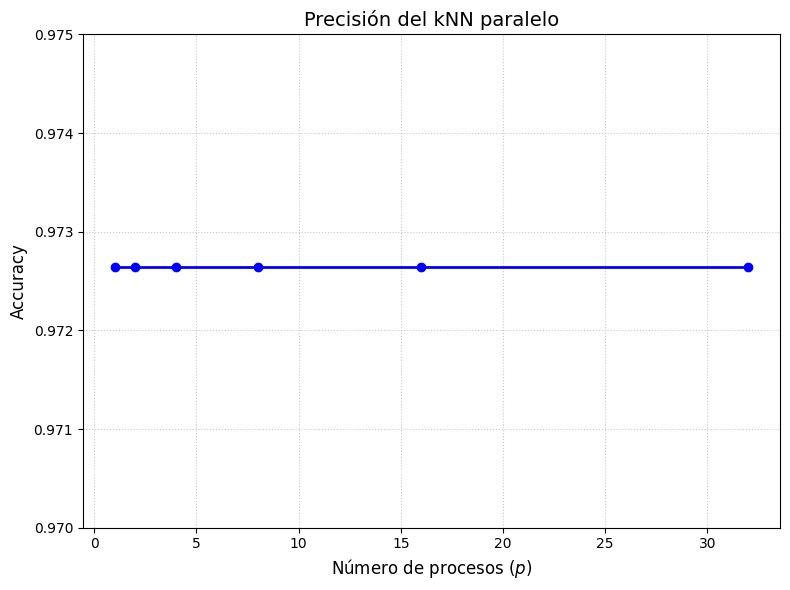

In [6]:
plt.figure(figsize=(8, 6))

plt.plot(df_100['Processes'], df_100['Accuracy'], marker='o', linestyle='-', color='b', linewidth=2)

plt.title('Precisión del kNN paralelo', fontsize=14)
plt.xlabel('Número de procesos ($p$)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

plt.ylim(0.97, 0.975)

plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()
plt.savefig("imgs/PRAM_Accuracy_plot.png", dpi=300, bbox_inches='tight')
plt.show()

### Cálculo del Speedup $S = T_s / T_p$

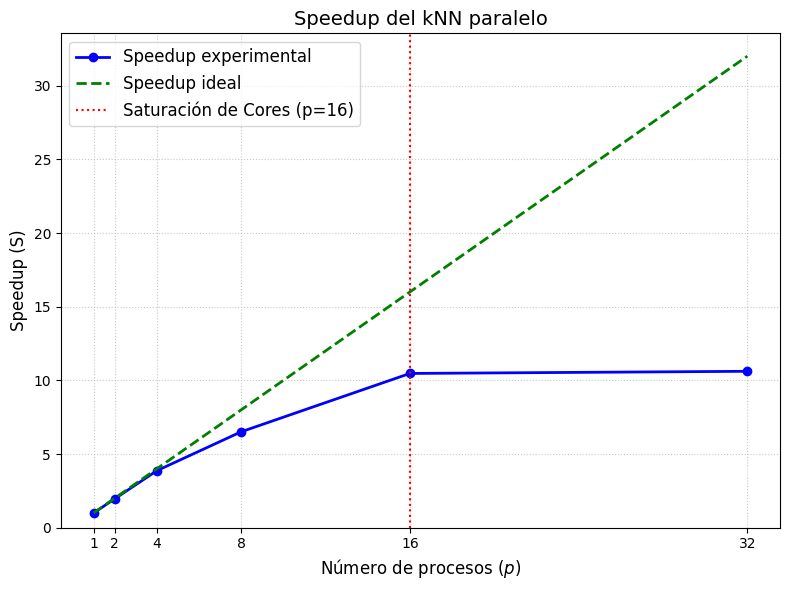

In [7]:
plt.figure(figsize=(8, 6))
plt.plot(df_100['Processes'], df_100['Speedup'], marker='o', linestyle='-', color='b', label='Speedup experimental', linewidth=2)
plt.plot(df_100['Processes'], df_100['Processes'], marker='', linestyle='--', color='g', label='Speedup ideal', linewidth=2)

plt.axvline(x=16, color='r', linestyle=':', linewidth=1.5, label='Saturación de Cores (p=16)')

plt.title('Speedup del kNN paralelo', fontsize=14)
plt.xlabel('Número de procesos ($p$)', fontsize=12)
plt.ylabel('Speedup (S)', fontsize=12)
plt.xticks(df_100['Processes'])
plt.ylim(bottom=0)
plt.grid(True, linestyle=":", alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("imgs/PRAM_Speedup_plot.png", dpi=300, bbox_inches='tight')
plt.show()

### FLOP/s de ejecución del kNN

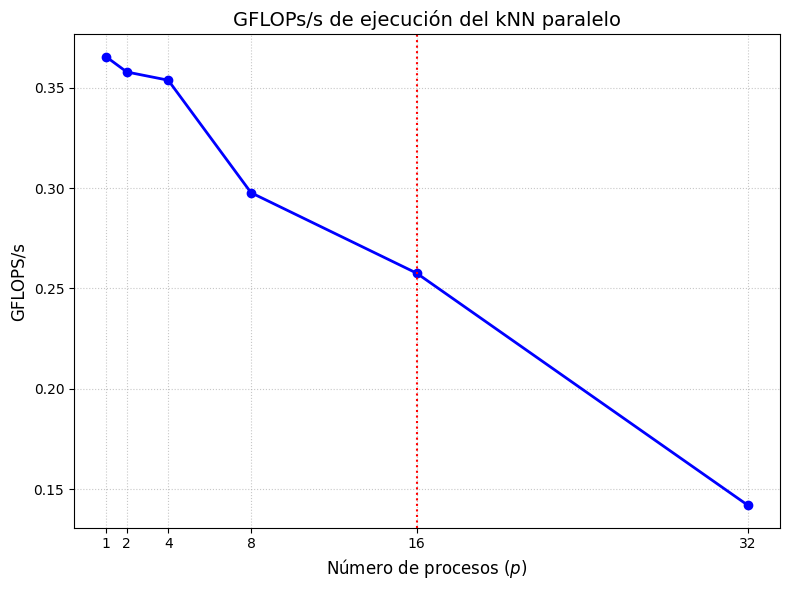

In [8]:
plt.figure(figsize=(8, 6))
plt.plot(df_100['Processes'], df_100['GFLOP/s'], marker='o', linestyle='-', color='b', linewidth=2)

plt.axvline(x=16, color='r', linestyle=':', linewidth=1.5, label='Saturación de Cores (p=16)')

plt.title('GFLOPs/s de ejecución del kNN paralelo', fontsize=14)
plt.xlabel('Número de procesos ($p$)', fontsize=12)
plt.ylabel('GFLOPS/s', fontsize=12)
plt.xticks(df_100['Processes'])
plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()
plt.savefig("imgs/PRAM_FLOPs_plot.png", dpi=300, bbox_inches='tight')
plt.show()

### Eficiencia del kNN paralelo

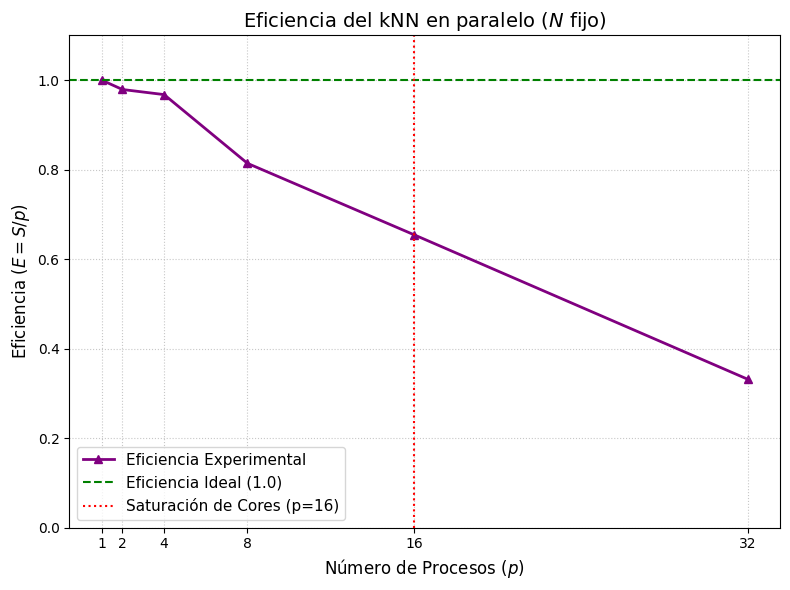

In [9]:
plt.figure(figsize=(8, 6))
plt.plot(df_100['Processes'], df_100['Efficiency'], marker='^', linestyle='-', color='purple', label='Eficiencia Experimental', linewidth=2)
plt.axhline(y=1.0, color='g', linestyle='--', label='Eficiencia Ideal (1.0)')

plt.axvline(x=16, color='r', linestyle=':', linewidth=1.5, label='Saturación de Cores (p=16)')

plt.title('Eficiencia del kNN en paralelo ($N$ fijo)', fontsize=14)
plt.xlabel('Número de Procesos ($p$)', fontsize=12)
plt.ylabel('Eficiencia ($E = S / p$)', fontsize=12)
plt.xticks(df_100['Processes'])
plt.ylim(0, 1.1)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig("imgs/PRAM_Eficiencia_plot.png", dpi=300, bbox_inches='tight')
plt.show()

### Gráficas con tamaño ($N$) variable

In [10]:
N = 56000 + 14000
subset_25 = int(N * 0.25)
subset_50 = int(N * 0.50)
subset_75 = int(N * 0.75)

print("N SIZES:")
print(f"- Subset  25%: {subset_25} samples")
print(f"- Subset  50%: {subset_50} samples")
print(f"- Subset  75%: {subset_75} samples")
print(f"- Subset 100%: {N} samples")

N SIZES:
- Subset  25%: 17500 samples
- Subset  50%: 35000 samples
- Subset  75%: 52500 samples
- Subset 100%: 70000 samples


In [11]:
df_mpi_np = df[df['Processes'] > 1]
procesos_unicos = sorted(df_mpi_np['Processes'].unique())

colores = cm.tab10(np.linspace(0, 1, len(procesos_unicos)))
marcadores = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', 'X', '<', '>']

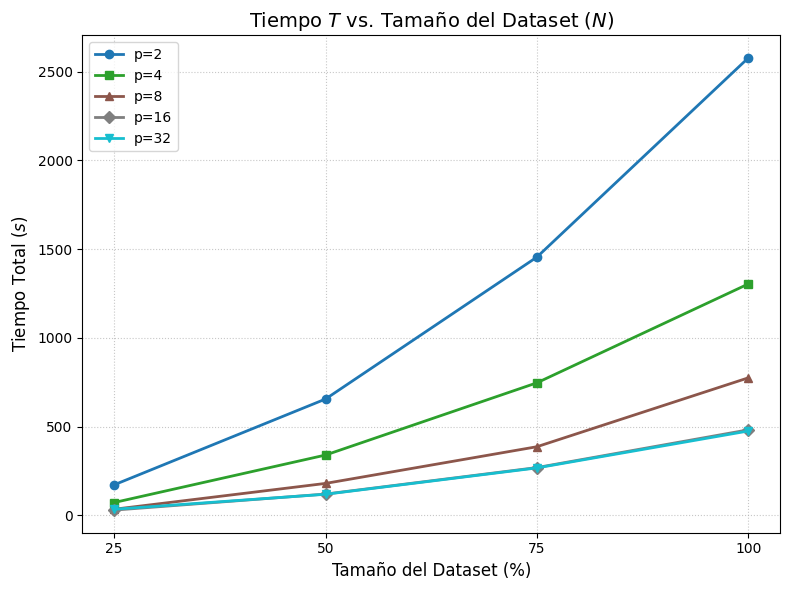

In [12]:
plt.figure(figsize=(8, 6))

for i, p in enumerate(procesos_unicos):
    df_p = df_mpi_np[df_mpi_np['Processes'] == p]
    plt.plot(df_p['Subset_%'], df_p['T_total (s)'], 
             marker=marcadores[i % len(marcadores)], color=colores[i], linewidth=2, label=f'p={p}')
    
plt.title('Tiempo $T$ vs. Tamaño del Dataset ($N$)', fontsize=14)
plt.xlabel('Tamaño del Dataset (%)', fontsize=12)
plt.ylabel('Tiempo Total ($s$)', fontsize=12)
plt.xticks([25, 50, 75, 100])
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=10)

plt.tight_layout()
plt.savefig("imgs/Tiempo_vs_N.png", dpi=300, bbox_inches='tight') 
plt.show()

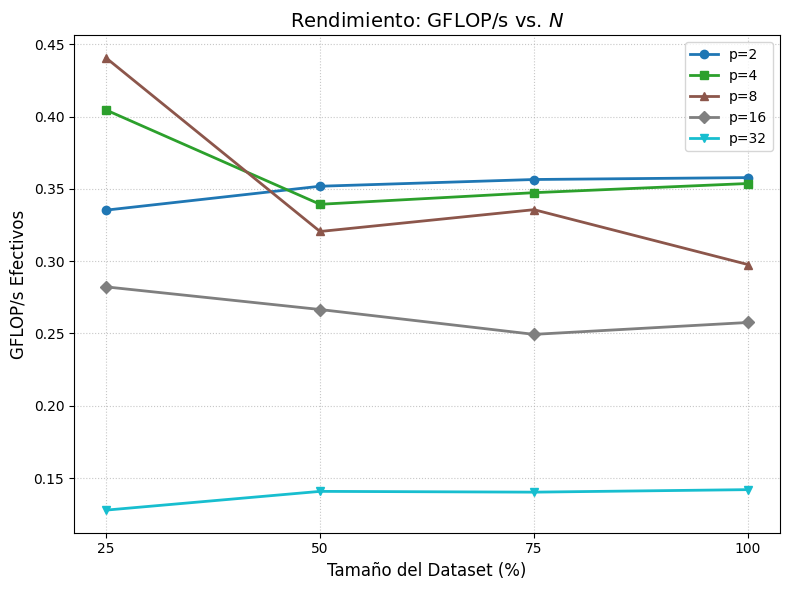

In [13]:
plt.figure(figsize=(8, 6))

for i, p in enumerate(procesos_unicos):
    df_p = df_mpi_np[df_mpi_np['Processes'] == p]
    plt.plot(df_p['Subset_%'], df_p['GFLOP/s'], 
             marker=marcadores[i % len(marcadores)], color=colores[i], linewidth=2, label=f'p={p}')
    
plt.title('Rendimiento: GFLOP/s vs. $N$', fontsize=14)
plt.xlabel('Tamaño del Dataset (%)', fontsize=12)
plt.ylabel('GFLOP/s Efectivos', fontsize=12)
plt.xticks([25, 50, 75, 100])
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=10)

plt.tight_layout()
plt.savefig("imgs/Rendimiento_GFLOPs.png", dpi=300, bbox_inches='tight')
plt.show()

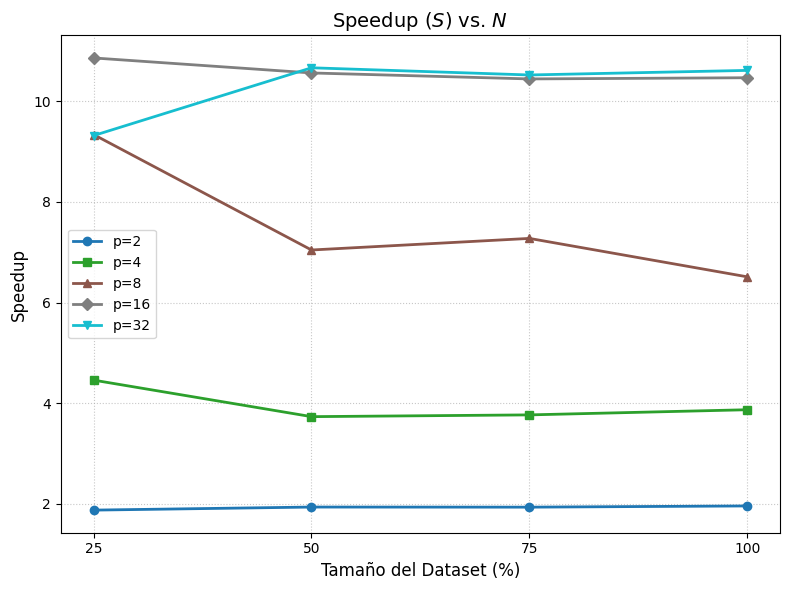

In [14]:
plt.figure(figsize=(8, 6))

for i, p in enumerate(procesos_unicos):
    df_p = df_mpi_np[df_mpi_np['Processes'] == p]
    plt.plot(df_p['Subset_%'], df_p['Speedup'], 
             marker=marcadores[i % len(marcadores)], color=colores[i], linewidth=2, label=f'p={p}')
    
plt.title('Speedup ($S$) vs. $N$', fontsize=14)
plt.xlabel('Tamaño del Dataset (%)', fontsize=12)
plt.ylabel('Speedup', fontsize=12)
plt.xticks([25, 50, 75, 100])
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=10)

plt.tight_layout()
plt.savefig("imgs/Speedup_vs_N.png", dpi=300, bbox_inches='tight')
plt.show()

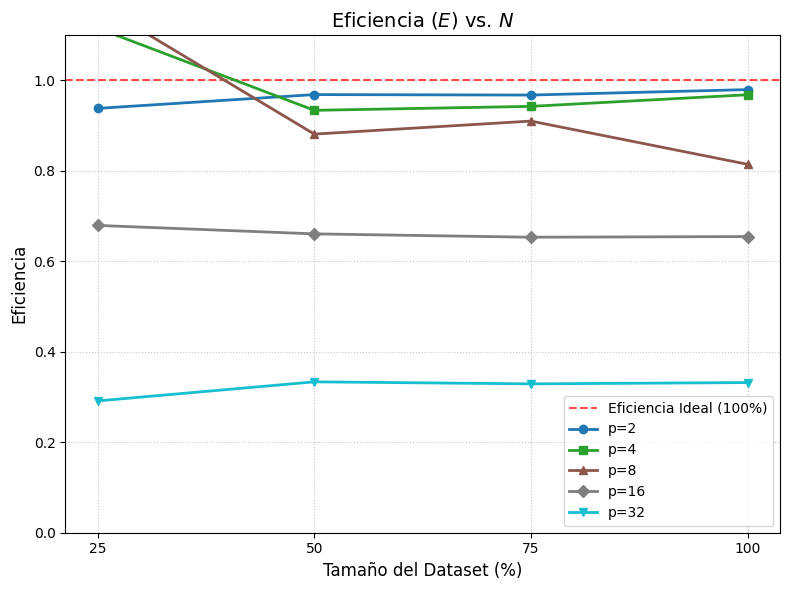

In [15]:
plt.figure(figsize=(8, 6))

plt.axhline(y=1.0, color='red', linestyle='--', label='Eficiencia Ideal (100%)', alpha=0.7)

for i, p in enumerate(procesos_unicos):
    df_p = df_mpi_np[df_mpi_np['Processes'] == p]
    plt.plot(df_p['Subset_%'], df_p['Efficiency'], 
             marker=marcadores[i % len(marcadores)], color=colores[i], linewidth=2, label=f'p={p}')
    
plt.title('Eficiencia ($E$) vs. $N$', fontsize=14)
plt.xlabel('Tamaño del Dataset (%)', fontsize=12)
plt.ylabel('Eficiencia', fontsize=12)
plt.xticks([25, 50, 75, 100])
plt.ylim(0, 1.1)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=10)

plt.tight_layout()
plt.savefig("imgs/Eficiencia_vs_N.png", dpi=300, bbox_inches='tight')
plt.show()